# 01 — Exploratory Data Analysis
### Project FORESIGHT — NorthBay Living

This notebook supports the findings in `reports/eda_insight_memo.md`. Run
`python src/pipeline.py` first so `data/processed/weekly_features.csv` exists.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

weekly = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week_start'])
clean_daily = pd.read_csv('../data/processed/clean_daily.csv', parse_dates=['date'])
weekly.head()

,sku_id,week_start,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,unit_cost,...,lag_4,lag_8,roll_mean_4,roll_mean_8,roll_std_4,seasonal_naive,on_hand_units,on_order_units,lead_time_days,reorder_point
0,SKU0055,2024-01-02,312.0,430889.47,1381.060000,5,0,Decor,Rugs,1115.69,...,NaN,NaN,NaN,NaN,NaN,NaN,493,311,25.0,517
1,SKU0111,2024-01-02,172.0,809458.15,4706.150000,5,0,Bedding,Comforters,3814.54,...,NaN,NaN,NaN,NaN,NaN,NaN,512,0,25.0,360
2,SKU0067,2024-01-02,178.0,884415.07,4968.620000,4,0,Bedding,Pillows,2464.96,...,NaN,NaN,NaN,NaN,NaN,NaN,619,0,26.0,532
3,SKU0115,2024-01-09,285.0,2244422.76,8132.860000,2,0,Decor,Rugs,3690.08,...,NaN,NaN,NaN,NaN,NaN,NaN,252,349,14.0,383
4,SKU0055,2024-01-09,252.0,401542.03,1627.674286,2,0,Decor,Rugs,1115.69,...,NaN,NaN,NaN,NaN,NaN,NaN,122,619,25.0,517


## 1. Overall weekly demand trend

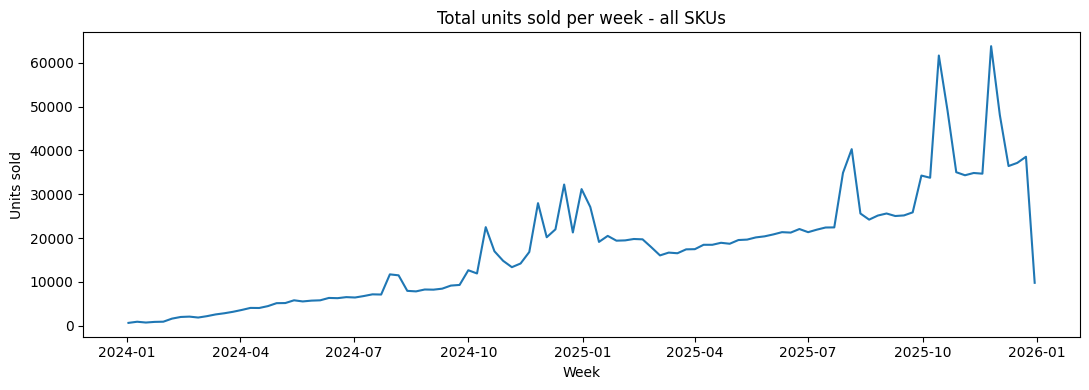

In [2]:
total_weekly = weekly.groupby('week_start')['units_sold'].sum()
plt.figure(figsize=(11,4))
plt.plot(total_weekly.index, total_weekly.values)
plt.title('Total units sold per week - all SKUs')
plt.xlabel('Week')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

## 2. Top movers vs. the long tail

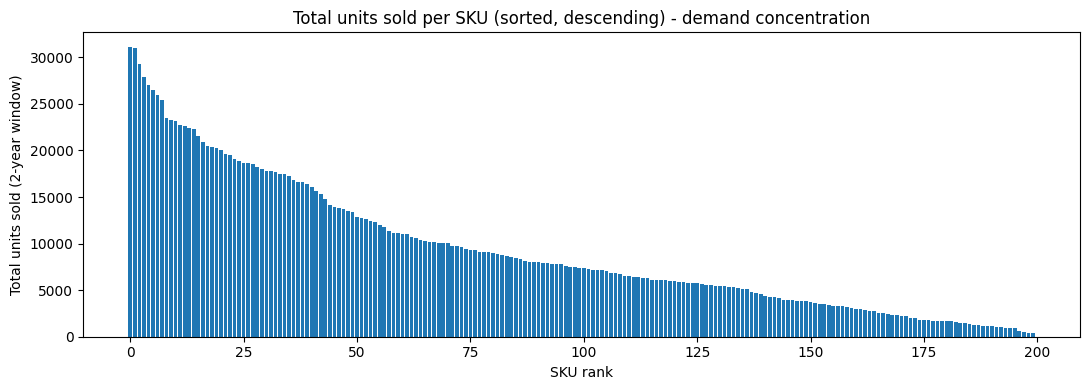

sku_id
SKU0180    31132.0
SKU0022    30986.0
SKU0025    29262.0
SKU0078    27902.0
SKU0023    27051.0
SKU0190    26514.0
SKU0148    26011.0
SKU0161    25445.0
SKU0035    23495.0
SKU0115    23315.0
Name: units_sold, dtype: float64

In [3]:
top_movers = weekly.groupby('sku_id')['units_sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(11,4))
plt.bar(range(len(top_movers)), top_movers.values)
plt.title('Total units sold per SKU (sorted, descending) - demand concentration')
plt.xlabel('SKU rank')
plt.ylabel('Total units sold (2-year window)')
plt.tight_layout()
plt.show()
top_movers.head(10)

## 3. Seasonality by category and month

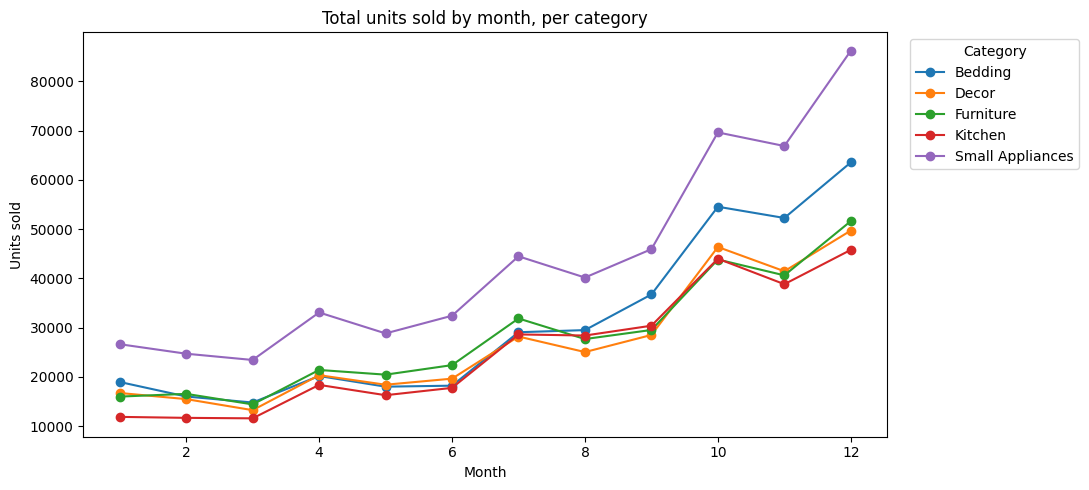

In [4]:
cat_month = weekly.groupby([weekly['week_start'].dt.month, 'category'])['units_sold'].sum().unstack()
cat_month.plot(figsize=(11,5), marker='o')
plt.title('Total units sold by month, per category')
plt.xlabel('Month')
plt.ylabel('Units sold')
plt.legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Promotion lift

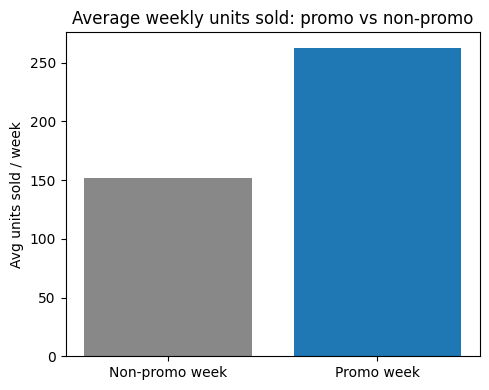

Non-promo week    152.059747
Promo week        262.629161
Name: units_sold, dtype: float64

In [5]:
promo_avg = weekly.groupby('is_promo_week')['units_sold'].mean()
promo_avg.index = ['Non-promo week', 'Promo week']
plt.figure(figsize=(5,4))
plt.bar(promo_avg.index, promo_avg.values, color=['#888','#1f77b4'])
plt.title('Average weekly units sold: promo vs non-promo')
plt.ylabel('Avg units sold / week')
plt.tight_layout()
plt.show()
promo_avg

## 5. Declining / dead-stock candidates

In [6]:
last_week = weekly['week_start'].max()
recent = weekly[weekly['week_start'] > last_week - pd.Timedelta(weeks=8)].groupby('sku_id')['units_sold'].sum()
prior = weekly[(weekly['week_start'] <= last_week - pd.Timedelta(weeks=8)) &
               (weekly['week_start'] > last_week - pd.Timedelta(weeks=16))].groupby('sku_id')['units_sold'].sum()
ratio = (recent / prior.replace(0, 1)).dropna().sort_values()
declining = ratio[ratio < 0.6]
print(f"{len(declining)} SKUs down more than 40 percent (last 8 weeks vs prior 8 weeks):")
declining.head(10)

3 SKUs down more than 40 percent (last 8 weeks vs prior 8 weeks):


sku_id
SKU0081    0.399083
SKU0038    0.438486
SKU0167    0.535912
Name: units_sold, dtype: float64

## Takeaways -> see `reports/eda_insight_memo.md` for the write-up in plain language.